# Unit 13 code companion: Choosing a Model

Optional unit. How much flexibility your data can pay for, and how to choose a model family out loud, before you see the answer.

Run the cells in order. Each section matches a moment in the slides. The point is to see the mechanism move when you change the inputs, so change them.

## Setup



In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score, learning_curve, train_test_split

rng = np.random.default_rng(0)
cars = pd.read_csv("https://richardson.byu.edu/220/cars.csv").dropna()
print(cars.shape)
cars.head(3)


(392, 9)


,mpg,cylinder,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130,3504,12.0,70,American,chevrolet
1,15.0,8,350.0,165,3693,11.5,70,American,buick
2,18.0,8,318.0,150,3436,11.0,70,American,plymouth


## 1. The live demo: commit before you see the test set

In class you picked a polynomial degree without seeing the held-out points. This is that demo. Change `class_picks` to whatever the room actually chose.

In [2]:

# 14 points everyone sees, 10 held out that nobody sees until the reveal.
sub = cars.sample(24, random_state=7)
seen, held = sub.iloc[:14], sub.iloc[14:]
x_seen, y_seen = seen[["weight"]].values, seen["mpg"].values
x_held, y_held = held[["weight"]].values, held["mpg"].values

class_picks = [1, 2, 3, 5, 8, 9]      # <- replace with the degrees the teams held up

def fit(d, x, y):
    m = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    return m.fit(x, y)

rows = []
for d in class_picks:
    m = fit(d, x_seen, y_seen)
    rows.append({
        "degree": d,
        "training error": np.mean((m.predict(x_seen) - y_seen) ** 2),
        "held-out error": np.mean((m.predict(x_held) - y_held) ** 2),
    })
board = pd.DataFrame(rows)
print("Leaderboard on the data everyone could see:")
print(board.sort_values("training error")[["degree", "training error"]].to_string(index=False))


Leaderboard on the data everyone could see:
 degree  training error
      9        4.439103
      8        4.445689
      5        4.659195
      3        6.021368
      2        6.635025
      1        6.878651


Now the reveal. Same teams, same fits, the 10 points they never saw.

Leaderboard on the held-out points:
 degree  held-out error
      1    2.404118e+01
      2    2.681221e+01
      3    4.714058e+01
      5    1.049898e+02
      8    9.257757e+04
      9    3.809802e+06


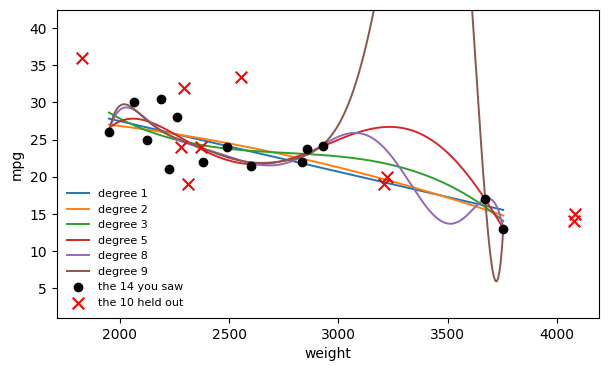

In [3]:

print("Leaderboard on the held-out points:")
print(board.sort_values("held-out error")[["degree", "held-out error"]].to_string(index=False))

grid = np.linspace(x_seen.min(), x_seen.max(), 300).reshape(-1, 1)
fig, ax = plt.subplots(figsize=(7, 4))
for d in class_picks:
    ax.plot(grid, fit(d, x_seen, y_seen).predict(grid), lw=1.4, label=f"degree {d}")
ax.scatter(x_seen, y_seen, color="black", zorder=5, label="the 14 you saw")
ax.scatter(x_held, y_held, color="red", marker="x", s=70, zorder=5, label="the 10 held out")
ax.set_ylim(y_seen.min() - 12, y_seen.max() + 12)
ax.set_xlabel("weight"); ax.set_ylabel("mpg"); ax.legend(fontsize=8, frameon=False)
plt.show()


## 2. Why the curve is U-shaped

Bias and variance are not metaphors. Both are computable if you simulate, because simulating means you know the truth.

In [4]:

truth = lambda x: 3.0 / (1 + np.exp(-3.2 * (x - 0.4))) + 0.45 * x
SD, XT = 0.6, np.linspace(-3, 3, 800)
YT = truth(XT)
degrees = range(1, 9)

def curves(n, reps=300, seed=1):
    r = np.random.default_rng(seed)
    P = np.zeros((len(list(degrees)), reps, len(XT)))
    for i in range(reps):
        x = r.uniform(-3, 3, n)
        y = truth(x) + r.normal(0, SD, n)
        for j, d in enumerate(degrees):
            P[j, i] = fit(d, x.reshape(-1, 1), y).predict(XT.reshape(-1, 1))
    return P

P = curves(n=60)
bias2 = ((P.mean(axis=1) - YT) ** 2).mean(axis=1)
var = P.var(axis=1).mean(axis=1)
out = pd.DataFrame({"degree": list(degrees), "bias^2": bias2.round(4),
                    "variance": var.round(4), "total": (bias2 + var).round(4)})
print(out.to_string(index=False))
print("\nbest degree:", out.loc[out['total'].idxmin(), 'degree'])


 degree  bias^2  variance  total
      1  0.2298    0.0181 0.2479
      2  0.1916    0.0280 0.2195
      3  0.0622    0.0311 0.0933
      4  0.0407    0.0409 0.0816
      5  0.0193    0.0488 0.0682
      6  0.0091    0.0638 0.0729
      7  0.0064    0.0875 0.0939
      8  0.0026    0.1361 0.1387

best degree: 5


Bias falls the whole way. Variance rises the whole way. Only the sum has a minimum.

## 3. Can you afford the truth?

The true curve is fixed. Only the number of rows changes. Watch the best degree move.

In [5]:

for n in (20, 50, 300):
    P = curves(n=n, reps=250, seed=3)
    err = np.median(((P - YT) ** 2).mean(axis=2), axis=1)
    best = list(degrees)[int(np.argmin(err))]
    print(f"n = {n:>3}   best degree = {best}   "
          f"cost of degree 8 relative to best = {err[-1] / err.min():.1f}x")


n =  20   best degree = 3   cost of degree 8 relative to best = 5.7x


n =  50   best degree = 6   cost of degree 8 relative to best = 1.4x


n = 300   best degree = 8   cost of degree 8 relative to best = 1.0x


## 4. Choosing honestly: the same folds for every family

Comparing families only means something when they face identical folds.

In [6]:

preds = ["weight", "displacement", "horsepower", "acceleration", "model_year", "cylinder"]
X, y = cars[preds].values, cars["mpg"].values
folds = KFold(5, shuffle=True, random_state=0)          # ONE fold object, reused

candidates = {
    "linear regression": make_pipeline(StandardScaler(), LinearRegression()),
    "lasso (CV-tuned)": make_pipeline(StandardScaler(), LassoCV(cv=5, random_state=0)),
    "random forest": RandomForestRegressor(n_estimators=300, random_state=0),
}
for name, model in candidates.items():
    s = -cross_val_score(model, X, y, cv=folds, scoring="neg_mean_squared_error")
    se = s.std(ddof=1) / np.sqrt(len(s))
    print(f"  {name:<20} CV MSE = {s.mean():6.2f}   SE = {se:4.2f}")


  linear regression    CV MSE =  12.23   SE = 0.86
  lasso (CV-tuned)     CV MSE =  12.15   SE = 0.82


  random forest        CV MSE =   7.44   SE = 0.77


**The one-standard-error rule.** If two families land within one SE of each other they are not distinguishable on this data, and you take the simpler one. Notice that the rule does *not* fire here: the forest wins by several times its standard error, so this is a real gap, not noise. That is the signal to go find what the forest is using.

## 5. Would more data help?

A learning curve answers the question the complexity table raises: is the ceiling here your model, or your sample size?

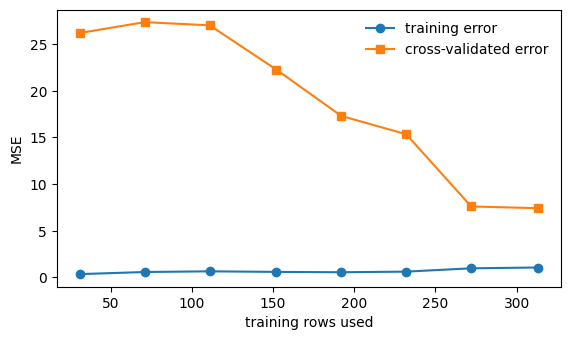

Still falling at the right edge means more data would still buy you something.


In [7]:

sizes, train_sc, test_sc = learning_curve(
    RandomForestRegressor(n_estimators=200, random_state=0), X, y,
    train_sizes=np.linspace(0.1, 1.0, 8), cv=folds, scoring="neg_mean_squared_error")

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(sizes, -train_sc.mean(axis=1), "o-", label="training error")
ax.plot(sizes, -test_sc.mean(axis=1), "s-", label="cross-validated error")
ax.set_xlabel("training rows used"); ax.set_ylabel("MSE"); ax.legend(frameon=False)
plt.show()
print("Still falling at the right edge means more data would still buy you something.")


## 6. The trap: importance is not an effect

Weight and displacement are nearly the same variable. Watch what that does to a ranking people routinely report as though it were a list of causes.

In [8]:

from collections import Counter

print("correlation between weight and displacement:",
      round(np.corrcoef(cars['weight'], cars['displacement'])[0, 1], 3))

# Resample the ROWS, which is the instability that actually matters.
tops, shares = [], []
r = np.random.default_rng(0)
for b in range(40):
    idx = r.integers(0, len(y), len(y))
    f = RandomForestRegressor(n_estimators=200, random_state=b).fit(X[idx], y[idx])
    s = pd.Series(f.feature_importances_, index=preds)
    tops.append(s.idxmax()); shares.append(s)

print("\nMost important variable, across 40 bootstrap resamples:")
for k, v in Counter(tops).most_common():
    print(f"  {k:<14} won {v:>2} times")

S = pd.DataFrame(shares)
print("\nImportance share, mean and range:")
for c in preds:
    print(f"  {c:<14} {S[c].mean():.3f}   [{S[c].min():.3f}, {S[c].max():.3f}]")


correlation between weight and displacement: 0.933



Most important variable, across 40 bootstrap resamples:
  displacement   won 26 times
  weight         won 10 times
  cylinder       won  3 times
  horsepower     won  1 times

Importance share, mean and range:
  weight         0.225   [0.072, 0.484]
  displacement   0.375   [0.069, 0.606]
  horsepower     0.143   [0.064, 0.322]
  acceleration   0.030   [0.018, 0.040]
  model_year     0.114   [0.068, 0.175]
  cylinder       0.113   [0.001, 0.494]


Four different variables take the top spot depending on which rows you happened to draw, and weight's share swings from 0.07 to 0.48. Now watch the two twins split credit.

In [9]:

full = RandomForestRegressor(n_estimators=300, random_state=0).fit(X, y)
keep = [p for p in preds if p != "displacement"]
dropped = RandomForestRegressor(n_estimators=300, random_state=0).fit(cars[keep].values, y)

print(f"weight importance, displacement present: {full.feature_importances_[0]:.3f}")
print(f"weight importance, displacement dropped: {dropped.feature_importances_[0]:.3f}")


weight importance, displacement present: 0.206
weight importance, displacement dropped: 0.303


Weight did not become a more important cause of fuel economy when we deleted a column. Its score went up because it stopped sharing credit with its twin. This is why an importance score is not something you report as a risk factor.

## What to take away




1. Flexibility is bought with sample size. Check the ratio before you check the algorithm.
2. Bias falls and variance rises. Only their sum has a minimum, and cross-validation finds it.
3. Compare families on identical folds, and break ties toward the simpler model.
4. A learning curve tells you whether your ceiling is the model or the data.
5. Importance scores rank correlated variables close to arbitrarily. They are not effects.
